In [1]:
import matplotlib.pyplot as plt 
import copy
import re
import numpy as np
from numpy import *
import pandas as pd
# Of the following charts, the ones with IID are based on the multikrumAgg aggregation alg., the ones non-IID are based on medianAgg aggregation alg.

In [2]:
retlog = "log_batchsize32.log"
accuracies = {}
losses = {}

dropoff_nonIID_para = {} # k: min_ratio_presence, v: dirichlet_alpha
dropoff_nonIID_para[1.0]=[0.1]
dropoff_nonIID_para[0.5]=[0.1,0.5,1.0]
dropoff_nonIID_para[0.8]=[0.1,0.5,1.0]

for num_clients in [100]:
    accuracies[num_clients]={}
    losses[num_clients]={}
    for min_ratio_presence in dropoff_nonIID_para:
        accuracies[num_clients][min_ratio_presence] = {}
        losses[num_clients][min_ratio_presence] = {}
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            accuracies[num_clients][min_ratio_presence][dirichlet_alpha]={}
            losses[num_clients][min_ratio_presence][dirichlet_alpha]={}
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type]=[]
                losses[num_clients][min_ratio_presence][dirichlet_alpha][sim_type]=[]

with open(retlog,'r') as f:
    flag = 0
    for line in f:
        line = line.rstrip()
        # read the settings of the simulation
        if line.startswith("["):
            flag=1
            markers=re.split('-',line)
            # get name of iidtype, simtype, attack type
            sim_type=markers[0]
            partition_type=markers[1]
            num_clients=int(markers[4].split('_')[2])
            min_ratio_presence=float(markers[5].split('_')[3])
            dirichlet_alpha=float(markers[6].split('_')[2])
            seed=int(markers[7].split('_')[1])
            # print(f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}, seed:{seed}")
        else:
            # only record the accuracy
            if flag == 1:
                acc_record = line.split(',')
                acc = []
                for _acc in acc_record:
                    acc.append(float(_acc))
                # print(f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}, seed:{seed}")
                accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type].append(acc)

            if flag == 2:
                loss_record = line.split(',')
                loss = []
                for _loss in loss_record:
                    loss.append(float(_loss))
                losses[num_clients][min_ratio_presence][dirichlet_alpha][sim_type].append(loss)
            flag += 1
            flag = flag % 3

FileNotFoundError: [Errno 2] No such file or directory: 'log_batchsize32.log'

In [24]:
# get average data
mean_acc = {}
for num_clients in [100]:
    mean_acc[num_clients] = {}
    for min_ratio_presence in dropoff_nonIID_para:
        mean_acc[num_clients][min_ratio_presence]={}
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            mean_acc[num_clients][min_ratio_presence][dirichlet_alpha]={}
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                if len(accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type])>0:
                    ret_array = np.array(accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type])
                    mean_acc[num_clients][min_ratio_presence][dirichlet_alpha][sim_type]=np.average(ret_array, axis=0)
                else:
                    mean_acc[num_clients][min_ratio_presence][dirichlet_alpha][sim_type] = np.array([])


In [25]:
print(f"Repeated simulations of each type")
for num_clients in [100]:
    for min_ratio_presence in dropoff_nonIID_para:
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                 str = f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}"
                 num = len(accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type])
                 print(f"{str} \t Repeated simulations: \t {num}")


Repeated simulations of each type
sim_type:[Sync_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Central_Sequential], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Central_RandOrder], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[DAGFL_GS_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[DAGFL_RandTips_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Async_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 1
sim_type:[Sync_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:0.5, dirichlet_alpha:0.1 	 Repeated simul

In [26]:
print(f"Repeated simulations of each type")
for num_clients in [100]:
    for min_ratio_presence in dropoff_nonIID_para:
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                 str = f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}"
                 num = len(accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type])
                 print(f"{str} \t Repeated simulations: \t {num}")


Repeated simulations of each type
sim_type:[Sync_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Central_Sequential], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Central_RandOrder], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[DAGFL_GS_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[DAGFL_RandTips_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 2
sim_type:[Async_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1 	 Repeated simulations: 	 1
sim_type:[Sync_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:0.5, dirichlet_alpha:0.1 	 Repeated simul

In [27]:
for num_clients in [100]:
    for min_ratio_presence in dropoff_nonIID_para:
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                # print(f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}, seed:{seed}")
                str = f"sim_type:{sim_type}, partition_type:{partition_type}, num_clients:{num_clients},min_ratio_presence:{min_ratio_presence}, dirichlet_alpha:{dirichlet_alpha}"
                # print(str)
                x = mean_acc[num_clients][min_ratio_presence][dirichlet_alpha][sim_type]
                if x.size >0:
                # if x.shape != ():
                    num = len(accuracies[num_clients][min_ratio_presence][dirichlet_alpha][sim_type])
                    print(f"{str}\t{x[0]}\t{x[-1]} \t Repeated simulations: \t {num}")

sim_type:[Sync_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.29059999999999997	0.9032 	 Repeated simulations: 	 2
sim_type:[Central_Sequential], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.8464	0.9796 	 Repeated simulations: 	 2
sim_type:[Central_RandOrder], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.8312999999999999	0.97885 	 Repeated simulations: 	 2
sim_type:[DAGFL_GS_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.2912	0.89755 	 Repeated simulations: 	 2
sim_type:[DAGFL_RandTips_alg.], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.2901	0.8986000000000001 	 Repeated simulations: 	 2
sim_type:[Async_FL], partition_type:dirichlet, num_clients:100,min_ratio_presence:1.0, dirichlet_alpha:0.1	0.2342	0.9034 	 Repeated simulations: 	 1
sim_type:[Central_Sequential], pa

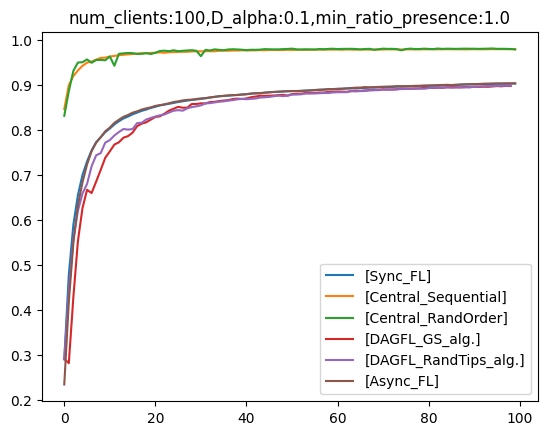

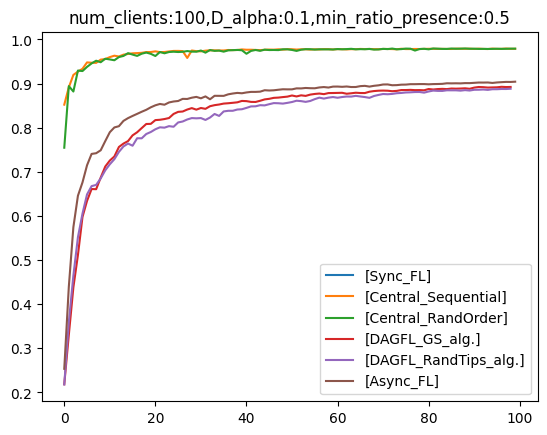

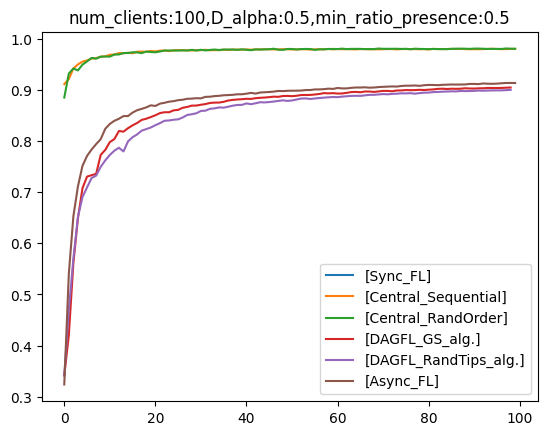

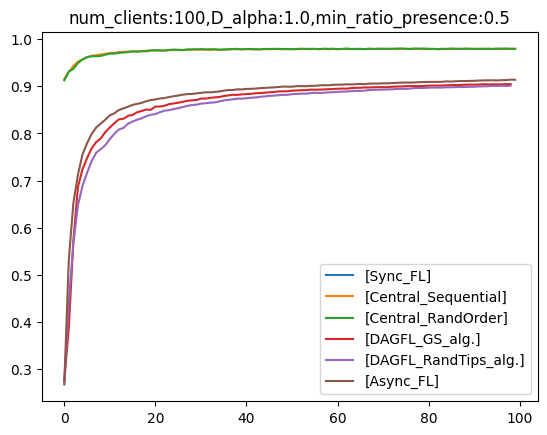

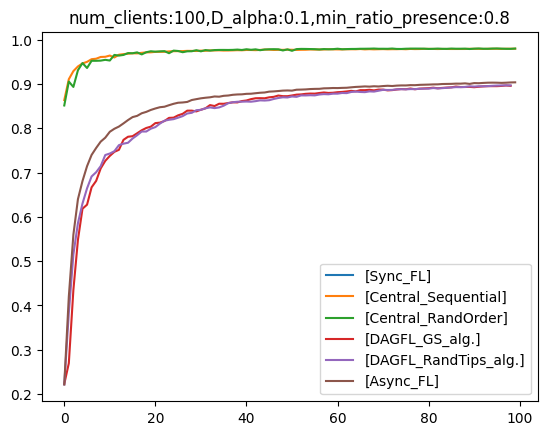

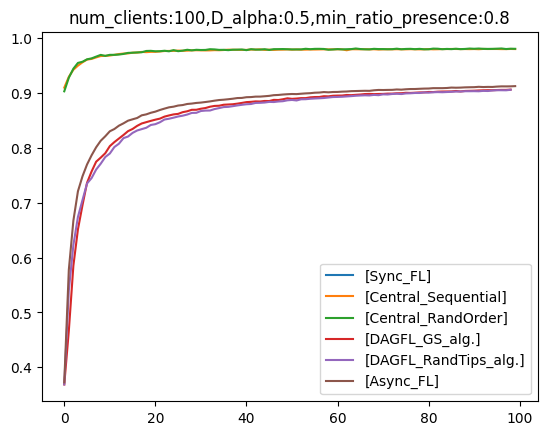

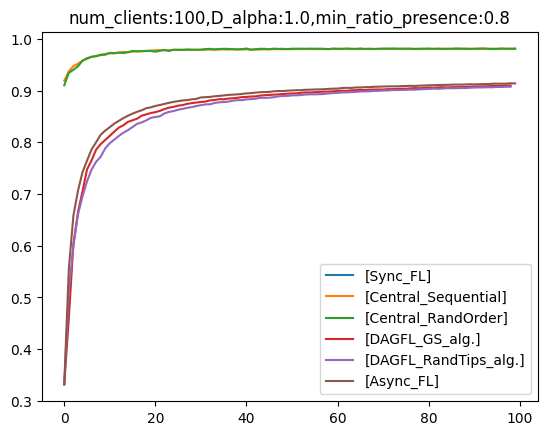

In [28]:
for num_clients in [100]:
    for min_ratio_presence in dropoff_nonIID_para:
        for dirichlet_alpha in dropoff_nonIID_para[min_ratio_presence]:
            for sim_type in ["[Sync_FL]","[Central_Sequential]","[Central_RandOrder]","[DAGFL_GS_alg.]","[DAGFL_RandTips_alg.]","[Async_FL]"]:
                label = sim_type
                title = f"num_clients:{num_clients},D_alpha:{dirichlet_alpha},min_ratio_presence:{min_ratio_presence}"
                y = mean_acc[num_clients][min_ratio_presence][dirichlet_alpha][sim_type]
                plt.plot(y, label= label)  # Default x-values: [0, 1, 2, 3, 4]
            plt.legend()
            plt.title(title)
            plt.show()
